In [1]:
import pandas as pd
import numpy as np

train_txn = pd.read_csv('../data/train_transaction.csv')
train_id = pd.read_csv('../data/train_identity.csv')

df = train_txn.merge(train_id, on='TransactionID', how='left')

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")

Shape: (590540, 434)
Fraud rate: 3.50%


# Exploratory Data Analysis

/var/folders/c7/vsbvjghd32923qb7b4qzsjr00000gn/T/ipykernel_60849/464930732.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amt = df.groupby('amt_bucket')['isFraud'].mean()


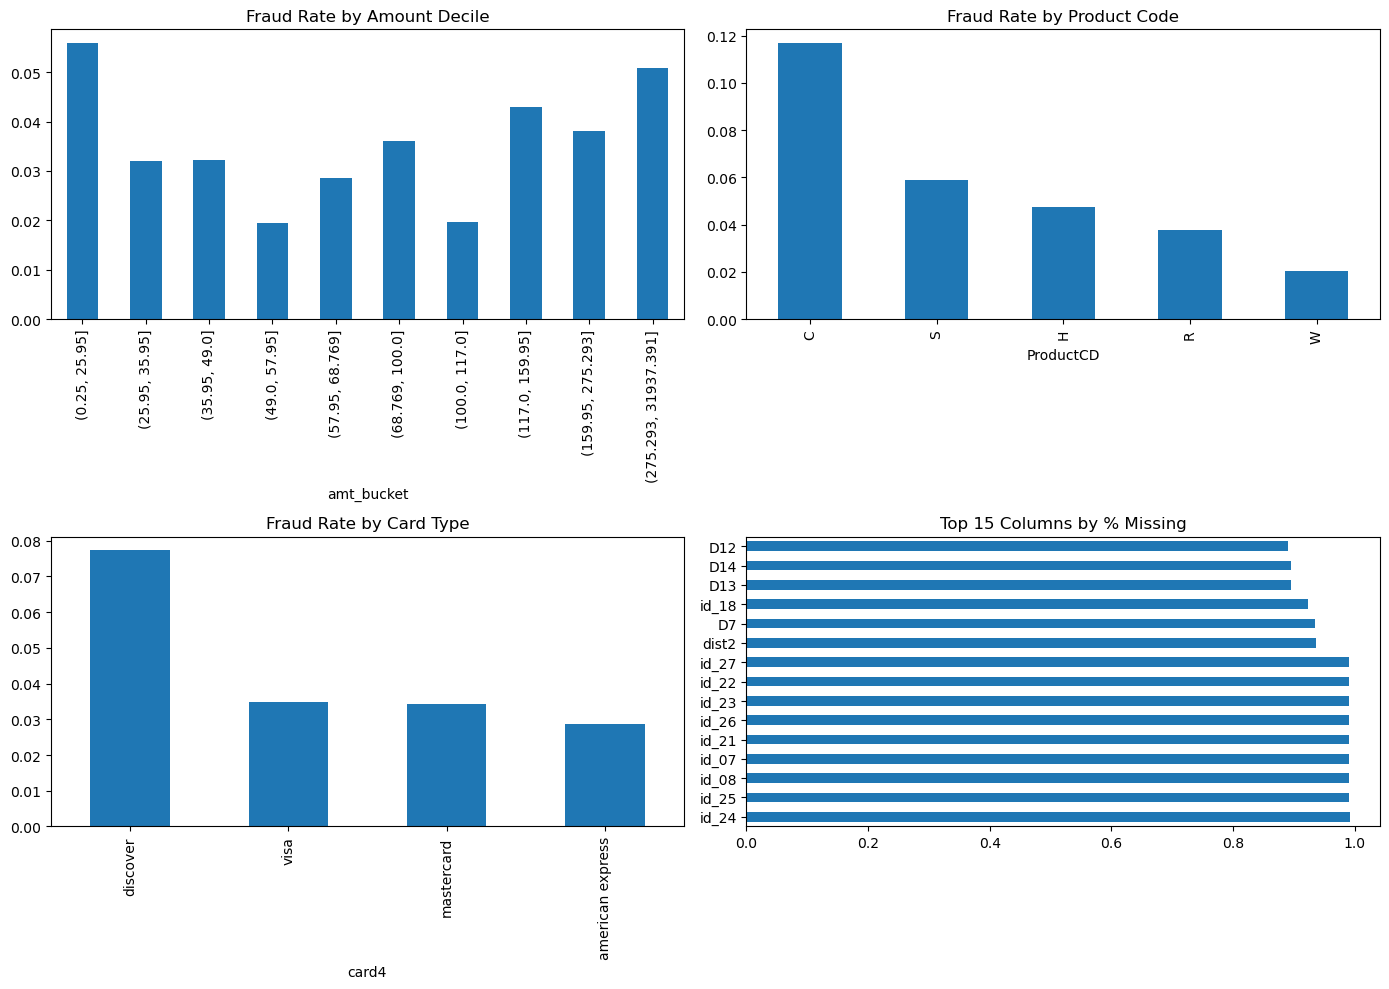

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fraud rate by transaction amount bucket
df['amt_bucket'] = pd.qcut(df['TransactionAmt'], q=10, duplicates='drop')
fraud_by_amt = df.groupby('amt_bucket')['isFraud'].mean()
fraud_by_amt.plot(kind='bar', ax=axes[0,0], title='Fraud Rate by Amount Decile')

# Fraud rate by product code
fraud_by_product = df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)
fraud_by_product.plot(kind='bar', ax=axes[0,1], title='Fraud Rate by Product Code')

# Fraud rate by card type
fraud_by_card = df.groupby('card4')['isFraud'].mean().sort_values(ascending=False)
fraud_by_card.plot(kind='bar', ax=axes[1,0], title='Fraud Rate by Card Type')

# Missing value % (important for this dataset — many columns are sparse)
missing_pct = df.isnull().mean().sort_values(ascending=False).head(15)
missing_pct.plot(kind='barh', ax=axes[1,1], title='Top 15 Columns by % Missing')

plt.tight_layout()
plt.savefig('../docs/eda_summary.png', dpi=150)
plt.show()

In [5]:
print(df['card4'].value_counts())
print(df.groupby('card4')['isFraud'].agg(['mean', 'count']))

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64
                      mean   count
card4                             
american express  0.028698    8328
discover          0.077282    6651
mastercard        0.034331  189217
visa              0.034756  384767


## EDA Findings
- Fraud rate follows a U-shape across transaction amount deciles -
  elevated in both the smallest (Approx. 5.7%) and largest (Approx. 5.3%) buckets, 
  consistent with card-testing (small) and cash-out (large) behavior.
- ProductCD 'C' carries a materially higher fraud rate (Approx. 12%) than 
  other product types — the single strongest categorical risk driver.
- Discover-branded transactions show elevated fraud rate (Approx. 7.5%) vs. 
  other card types (Approx. 3%), though this needs volume-checking before 
  treating as a stable driver.
- Discover-branded transactions show a materially elevated fraud rate (7.73%) versus Visa and Mastercard (~3.4-3.5%), based on a sample of     6,651 transactions — large enough to be a credible signal, though Discover represents only ~1% of total transaction volume, so this driver   affects a narrow but high-risk segment rather than the bulk of the portfolio
- Identity fields (id_*) are heavily sparse (many >90% missing), 
  requiring careful missing-value handling in feature engineering.

## Fraud Risk Driver Summary

**Business question:** What transaction, card, and account characteristics are 
associated with elevated fraud risk in this portfolio?

1. **Transaction amount** follows a U-shaped fraud pattern - elevated in both 
   the smallest (Approx 5.7%) and largest (Approx 5.3%) deciles, consistent with card-testing 
   (small, low-risk probes) and cash-out (large, high-value extraction) behavior.

2. **Product category is the single strongest driver**: Product C shows a ~12% 
   fraud rate, roughly 3-4x higher than other product categories.

3. **Card type (credit vs. debit)** is a strong, high-volume driver: credit 
   transactions show 6.68% fraud vs. 2.43% for debit — nearly 3x higher risk, 
   based on a well-represented 149K-transaction segment.

4. **Card network** shows a smaller-volume anomaly: Discover transactions show 
   7.73% fraud vs. Approx 3.4-3.5% for Visa/Mastercard, though Discover represents 
   only ~1% of total volume.

5. **Email domain** shows meaningful spread among high-volume providers: 
   outlook.com (9.5%) and hotmail.com (5.3%) run notably higher than 
   ISP-tied domains like att.net (0.7%) and sbcglobal.net (0.4%).

**Implication:** card type and product category are the highest-confidence, 
highest-volume drivers to prioritize operationally; card network and email 
domain provide secondary, smaller-segment signal.

In [4]:
print(f"Unique card1 values: {df['card1'].nunique()}")
print(f"Total transactions: {len(df)}")
print(f"Avg transactions per card1: {len(df) / df['card1'].nunique():.1f}")

# Distribution check - how many cards have just 1 transaction vs many?
card1_counts = df['card1'].value_counts()
print(card1_counts.describe())

Unique card1 values: 13553
Total transactions: 590540
Avg transactions per card1: 43.6
count    13553.000000
mean        43.572641
std        329.084462
min          1.000000
25%          1.000000
50%          4.000000
75%         14.000000
max      14932.000000
Name: count, dtype: float64


In [3]:
# Transactions per account in trailing windows (velocity proxy)
# card1 acts as a pseudo account identifier in this dataset
df = df.sort_values('TransactionDT')

df['card1_txn_count_total'] = df.groupby('card1')['card1'].transform('count')

# Change in typical transaction amount vs account's historical average
df['card1_avg_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['amt_deviation'] = df['TransactionAmt'] / df['card1_avg_amt']

print(df[['card1', 'TransactionAmt', 'card1_avg_amt', 'amt_deviation', 'card1_txn_count_total']].head(10))

   card1  TransactionAmt  card1_avg_amt  amt_deviation  card1_txn_count_total
0  13926            68.5     351.931163       0.194640                     43
1   2755            29.0     234.292753       0.123777                    683
2   4663            59.0      97.015542       0.608150                   1108
3  18132            50.0     123.416340       0.405133                   4209
4   4497            50.0      96.972222       0.515612                     18
5   5937            49.0     134.071429       0.365477                      7
6  12308           159.0     101.880097       1.560658                    207
7  12695           422.5     141.144645       2.993383                   7091
8   2803            15.0     142.683409       0.105128                   6141
9  17399           117.0     122.020491       0.958855                   1916


In [6]:
print(df.groupby('isFraud')['amt_deviation'].describe())

            count      mean       std       min       25%       50%       75%  \
isFraud                                                                         
0        569877.0  0.993358  1.362812  0.002787  0.380933  0.630832  1.090754   
1         20663.0  1.183173  1.445098  0.007401  0.442003  0.810718  1.433882   

                max  
isFraud              
0        114.123913  
1         44.866762  


- Transaction amount deviation from a card's historical average (amt_deviation) 
  shows a directionally consistent but moderate fraud signal - fraudulent 
  transactions average 1.18x the card's typical spend vs. 0.99x for legitimate 
  transactions, with fraud's median and 75th percentile also shifted higher. 
  The distributions overlap substantially, so this behaves as a contributing 
  signal rather than a standalone discriminator.

In [7]:
print(df.groupby('P_emaildomain')['isFraud'].agg(['mean', 'count']).sort_values('count', ascending=False).head(15))

                   mean   count
P_emaildomain                  
gmail.com      0.043542  228355
yahoo.com      0.022757  100934
hotmail.com    0.052950   45250
anonymous.com  0.023217   36998
aol.com        0.021811   28289
comcast.net    0.031187    7888
icloud.com     0.031434    6267
outlook.com    0.094584    5096
msn.com        0.021994    4092
att.net        0.007439    4033
live.com       0.027622    3041
sbcglobal.net  0.004040    2970
verizon.net    0.008133    2705
ymail.com      0.020868    2396
bellsouth.net  0.027763    1909


In [8]:
candidate_features = ['C1', 'C2', 'C13', 'C14', 'D1', 'D4', 'D15']
print(df[candidate_features + ['isFraud']].corr()['isFraud'].sort_values(ascending=False))

isFraud    1.000000
C2         0.037229
C1         0.030570
C14        0.007921
C13       -0.011146
D1        -0.067193
D4        -0.067216
D15       -0.077519
Name: isFraud, dtype: float64


- Email domain shows meaningful fraud-rate variation among high-volume domains 
  (outlook.com 9.5%, hotmail.com 5.3%, vs. att.net 0.7%, sbcglobal.net 0.4%), 
  supporting its use as a categorical risk driver.
- Anonymized count features (C1-C14) and time-delta features (D1-D15) show weak 
  linear correlation with fraud individually (|r| < 0.08 for all candidates 
  tested) - likely still useful in combination with other features via the 
  model, but not standalone strong predictors on their own.

In [9]:
print(df['card6'].value_counts())
print(df.groupby('card6')['isFraud'].agg(['mean', 'count']))

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64
                     mean   count
card6                            
charge card      0.000000      15
credit           0.066785  148986
debit            0.024263  439938
debit or credit  0.000000      30


- Card type is a strong risk driver: credit card transactions show a fraud 
  rate of 6.68% versus 2.43% for debit (148,986 and 439,938 transactions 
  respectively) - nearly 3x higher risk, and unlike the card-network finding, 
  based on a large, well-represented segment rather than a small niche.

In [10]:
pd.set_option('display.max_rows', None)
col_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'pct_missing': df.isnull().mean() * 100,
    'n_unique': df.nunique()
}).sort_values('pct_missing')

print(col_summary)

                          dtype  pct_missing  n_unique
TransactionID             int64     0.000000    590540
C4                      float64     0.000000      1260
C5                      float64     0.000000       319
C6                      float64     0.000000      1328
C7                      float64     0.000000      1103
C8                      float64     0.000000      1253
C9                      float64     0.000000       205
C3                      float64     0.000000        27
C10                     float64     0.000000      1231
C12                     float64     0.000000      1199
C13                     float64     0.000000      1597
C14                     float64     0.000000      1108
card1_avg_amt           float64     0.000000      9218
amt_bucket             category     0.000000        10
card1_txn_count_total     int64     0.000000       517
C11                     float64     0.000000      1476
C2                      float64     0.000000      1216
amt_deviat

In [11]:
col_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'pct_missing': df.isnull().mean() * 100,
    'n_unique': df.nunique()
})

# Bucket into missingness tiers for a quick overview
def missing_tier(pct):
    if pct == 0:
        return '0% missing'
    elif pct < 10:
        return '<10% missing'
    elif pct < 50:
        return '10-50% missing'
    elif pct < 90:
        return '50-90% missing'
    else:
        return '>90% missing'

col_summary['missing_tier'] = col_summary['pct_missing'].apply(missing_tier)

# High-level counts per tier - tells you where most columns fall
print(col_summary['missing_tier'].value_counts())

missing_tier
50-90% missing    202
10-50% missing    108
<10% missing       92
0% missing         24
>90% missing       12
Name: count, dtype: int64


In [12]:
already_checked = ['TransactionAmt', 'ProductCD', 'card4', 'card6', 'P_emaildomain',
                    'C1', 'C2', 'C13', 'C14', 'D1', 'D4', 'D15', 'isFraud',
                    'TransactionID', 'TransactionDT']

unexplored = col_summary[
    (col_summary['pct_missing'] < 10) &
    (~col_summary.index.isin(already_checked))
].sort_values('n_unique')

pd.set_option('display.max_rows', None)
print(unexplored)

                          dtype  pct_missing  n_unique  missing_tier
V305                    float64     0.002032         2  <10% missing
V107                    float64     0.053172         2  <10% missing
V121                    float64     0.053172         4  <10% missing
V120                    float64     0.053172         4  <10% missing
V119                    float64     0.053172         4  <10% missing
V118                    float64     0.053172         4  <10% missing
V117                    float64     0.053172         4  <10% missing
V122                    float64     0.053172         4  <10% missing
V116                    float64     0.053172         7  <10% missing
V115                    float64     0.053172         7  <10% missing
V114                    float64     0.053172         7  <10% missing
V110                    float64     0.053172         8  <10% missing
V109                    float64     0.053172         8  <10% missing
V108                    float64   

The dataset includes 339 anonymized 'V' features (Vesta-engineered, semantics undisclosed). Rather than manually inspecting each in isolation, these are excluded from the interpretable feature set used for the primary logistic regression model, but will be assessed in aggregate via feature importance in the Random Forest/XGBoost benchmark model (Phase 2.2), where their collective predictive value can be evaluated without requiring individual interpretability.

In [13]:
print(df[['card2', 'card3', 'card5', 'isFraud']].corr()['isFraud'])

card2      0.003388
card3      0.154151
card5     -0.033580
isFraud    1.000000
Name: isFraud, dtype: float64


In [14]:
print(col_summary.loc[['addr1', 'addr2', 'dist1']])

         dtype  pct_missing  n_unique    missing_tier
addr1  float64    11.126427       332  10-50% missing
addr2  float64    11.126427        74  10-50% missing
dist1  float64    59.652352      2651  50-90% missing


In [15]:
print(df.groupby('addr2')['isFraud'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10))

           mean   count
addr2                  
87.0   0.023972  520481
60.0   0.090467    3084
96.0   0.139498     638
32.0   0.065934      91
65.0   0.536585      82
16.0   0.000000      55
31.0   0.000000      47
19.0   0.000000      33
26.0   0.000000      25
27.0   0.000000      20


### Train/Test Split

In [16]:
from sklearn.model_selection import train_test_split

# Drop the leaky versions we built earlier
df = df.drop(columns=['card1_txn_count_total', 'card1_avg_amt', 'amt_deviation'])

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['isFraud']
)

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

Train shape: (472432, 435), Test shape: (118108, 435)


### Compute card1-level statistics using ONLY the training set

In [17]:
# Compute these stats from train_df only
card1_stats = train_df.groupby('card1').agg(
    card1_txn_count_total=('card1', 'count'),
    card1_avg_amt=('TransactionAmt', 'mean')
).reset_index()

print(card1_stats.head())
print(f"Unique card1 values seen in training: {len(card1_stats)}")

   card1  card1_txn_count_total  card1_avg_amt
0   1001                      3      79.666667
1   1004                      4     163.000000
2   1006                      2     125.000000
3   1007                      1      23.203000
4   1008                      2      78.975000
Unique card1 values seen in training: 12821


### Mapping those train-derived stats onto both train and test

In [18]:
# Merge onto train
train_df = train_df.merge(card1_stats, on='card1', how='left')

# Merge onto test - some card1 values in test may not exist in train (unseen cards)
test_df = test_df.merge(card1_stats, on='card1', how='left')

# For card1 values in test that were never seen in train, fill with train-wide defaults
global_avg_amt = train_df['TransactionAmt'].mean()
global_txn_count = train_df['card1_txn_count_total'].median()

test_df['card1_avg_amt'] = test_df['card1_avg_amt'].fillna(global_avg_amt)
test_df['card1_txn_count_total'] = test_df['card1_txn_count_total'].fillna(global_txn_count)

# Now compute amt_deviation on both, using only train-derived averages
train_df['amt_deviation'] = train_df['TransactionAmt'] / train_df['card1_avg_amt']
test_df['amt_deviation'] = test_df['TransactionAmt'] / test_df['card1_avg_amt']

print(f"Unseen card1 values in test: {test_df['card1_avg_amt'].isna().sum()}")

Unseen card1 values in test: 0


In [19]:
features = [
    'TransactionAmt', 'ProductCD', 'card3', 'card4', 'card6', 'P_emaildomain',
    'C1', 'C2', 'D1', 'D4', 'D15',
    'amt_deviation', 'card1_txn_count_total'
]

# Check missingness in the final feature set before encoding
print(train_df[features].isnull().sum())

TransactionAmt                0
ProductCD                     0
card3                      1236
card4                      1244
card6                      1241
P_emaildomain             75583
C1                            0
C2                            0
D1                         1036
D4                       135310
D15                       71385
amt_deviation                 0
card1_txn_count_total         0
dtype: int64


In [20]:
print(train_df[['D1', 'D4', 'D15']].describe())

                  D1             D4            D15
count  471396.000000  337122.000000  401047.000000
mean       94.263110     139.879450     163.745152
std       157.576437     191.016194     202.725706
min         0.000000    -122.000000     -83.000000
25%         0.000000       0.000000       0.000000
50%         3.000000      26.000000      52.000000
75%       122.000000     253.000000     314.000000
max       640.000000     864.000000     879.000000


- D1, D4, and D15 all show severe right-skew (e.g., D1: mean=94.3 vs 
  median=3.0, a >30x gap), driven by a long tail of large values. Median 
  imputation was used for missing values in these columns to avoid inflating 
  imputed values toward the skewed mean. D4 and D15 also contain negative 
  values, suggesting their time-delta reference point isn't simply "time 
  since this transaction."

### Handling missing values

In [21]:
# Categorical fills
cat_cols = ['ProductCD', 'card3', 'card4', 'card6', 'P_emaildomain']
for col in cat_cols:
    train_df[col] = train_df[col].fillna('missing').astype(str)
    test_df[col] = test_df[col].fillna('missing').astype(str)

# Numeric fills - compute median from TRAIN only
num_cols = ['D1', 'D4', 'D15']
for col in num_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

# Confirm no missingness remains
print("Train missing:", train_df[features].isnull().sum().sum())
print("Test missing:", test_df[features].isnull().sum().sum())

Train missing: 0
Test missing: 0


### Encoding categoricals

In [22]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['ProductCD', 'card3', 'card4', 'card6', 'P_emaildomain']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Fit on train only
    le.fit(train_df[col])
    train_df[col] = le.transform(train_df[col])
    
    # Apply to test - handle categories unseen in train
    test_df[col] = test_df[col].apply(lambda x: x if x in le.classes_ else 'missing')
    # Re-fit classes_ to include 'missing' if it wasn't already there, then transform
    if 'missing' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'missing')
    test_df[col] = le.transform(test_df[col])
    
    encoders[col] = le  # keep for reference/inverse_transform later

print(train_df[cat_cols].head())
print(test_df[cat_cols].head())

   ProductCD  card3  card4  card6  P_emaildomain
0          2     41      0      1              1
1          4     41      2      2             16
2          4     41      4      1              9
3          4     41      1      1             31
4          4     41      4      2             31
   ProductCD  card3  card4  card6  P_emaildomain
0          4     41      4      1              2
1          0     72      2      2             19
2          4     41      2      2             31
3          4     41      4      2             16
4          4     41      4      2              2


## Primary Model - Logistic Regression

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report

X_train = train_df[features]
y_train = train_df['isFraud']
X_test = test_df[features]
y_test = test_df['isFraud']

# Scale - fit on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict probabilities on test
y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.7461


In [24]:
import numpy as np

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print(coef_df)

                  feature  coefficient  odds_ratio
7                      C2     0.828787    2.290539
2                   card3     0.277988    1.320471
0          TransactionAmt     0.106827    1.112742
3                   card4     0.086553    1.090409
11          amt_deviation     0.082193    1.085665
5           P_emaildomain     0.028491    1.028901
12  card1_txn_count_total     0.021765    1.022004
9                      D4    -0.075053    0.927695
10                    D15    -0.108742    0.896962
8                      D1    -0.216928    0.804988
1               ProductCD    -0.269564    0.763713
4                   card6    -0.327461    0.720751
6                      C1    -0.777595    0.459510


In [25]:
for col in ['ProductCD', 'card4', 'card6', 'P_emaildomain']:
    print(f"\n{col} encoding:")
    print(dict(zip(encoders[col].classes_, range(len(encoders[col].classes_)))))


ProductCD encoding:
{'C': 0, 'H': 1, 'R': 2, 'S': 3, 'W': 4, 'missing': 5}

card4 encoding:
{'american express': 0, 'discover': 1, 'mastercard': 2, 'missing': 3, 'visa': 4}

card6 encoding:
{'charge card': 0, 'credit': 1, 'debit': 2, 'debit or credit': 3, 'missing': 4}

P_emaildomain encoding:
{'aim.com': 0, 'anonymous.com': 1, 'aol.com': 2, 'att.net': 3, 'bellsouth.net': 4, 'cableone.net': 5, 'centurylink.net': 6, 'cfl.rr.com': 7, 'charter.net': 8, 'comcast.net': 9, 'cox.net': 10, 'earthlink.net': 11, 'embarqmail.com': 12, 'frontier.com': 13, 'frontiernet.net': 14, 'gmail': 15, 'gmail.com': 16, 'gmx.de': 17, 'hotmail.co.uk': 18, 'hotmail.com': 19, 'hotmail.de': 20, 'hotmail.es': 21, 'hotmail.fr': 22, 'icloud.com': 23, 'juno.com': 24, 'live.com': 25, 'live.com.mx': 26, 'live.fr': 27, 'mac.com': 28, 'mail.com': 29, 'me.com': 30, 'missing': 31, 'msn.com': 32, 'netzero.com': 33, 'netzero.net': 34, 'optonline.net': 35, 'outlook.com': 36, 'outlook.es': 37, 'prodigy.net.mx': 38, 'protonmail

- **Limitation & next step:** LabelEncoder's arbitrary integer assignment works 
  reasonably for ProductCD and card6 (where risk happens to align with encoding 
  order) but fails to capture card4's non-monotonic pattern (Discover's elevated 
  risk sits mid-scale). Target encoding (category → smoothed fraud rate) would 
  resolve this for linear models; deferred here in favor of evaluating whether 
  the tree-based benchmark model handles this natively.

- **Future work — target encoding:** Testing target encoding (category → 
  smoothed fraud rate) on card4 specifically would likely improve its 
  coefficient's interpretability and may offer a modest AUC gain, since its 
  true risk ordering (Discover elevated, mid-scale in the current arbitrary 
  encoding) isn't captured by LabelEncoder. Expected impact is likely small 
  given card4's already-modest coefficient, but would matter more for 
  higher-cardinality features (e.g., P_emaildomain's 60 categories) if 
  those were expanded in a future iteration. Deferred here in favor of 
  evaluating whether tree-based models handle this natively.

## Random Forest/XGBoost benchmarking

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # use all available CPU cores for speed
)

# Note: tree-based models don't need scaled features - use raw X_train/X_test
rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")
print(f"Logistic Regression ROC-AUC: {auc:.4f}")

Random Forest ROC-AUC: 0.8799
Logistic Regression ROC-AUC: 0.7461


Selected logistic regression as the primary model for interpretability in a regulated decision context - where being able to explain why a transaction was flagged matters as much as flagging it correctly - benchmarked against Random Forest (0.88 vs. 0.75 ROC-AUC) to confirm we weren't leaving material predictive lift on the table. The gap suggests roughly 13 points of AUC value in non-linear feature interactions and categorical handling, a cost worth weighing against the interpretability benefit for a compliance-sensitive fraud program.

In [27]:
rf_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(rf_importance)

                  feature  importance
1               ProductCD    0.146943
6                      C1    0.108401
2                   card3    0.108274
7                      C2    0.104488
8                      D1    0.097336
10                    D15    0.095823
4                   card6    0.075900
0          TransactionAmt    0.071494
12  card1_txn_count_total    0.053450
9                      D4    0.051888
11          amt_deviation    0.040810
5           P_emaildomain    0.034094
3                   card4    0.011099


card4 ranked lowest in Random Forest feature importance (0.011) as well as logistic regression's odds ratio, despite showing a real fraud-rate difference in EDA (Discover 7.7% vs. Visa/Mastercard ~3.5%). This suggests card4's raw fraud-rate signal is substantially redundant with other features already in the model (e.g., card3, card6) rather than solely an artifact of LabelEncoder's ordinal assumption - target encoding might still marginally help the logistic regression's interpretability, but is unlikely to meaningfully lift overall predictive power given both models converge on this feature being weak.

## Validation

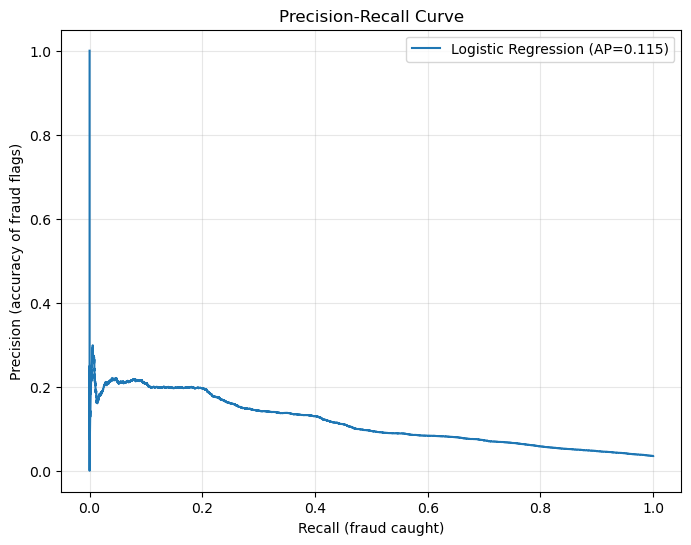

Average Precision (AP): 0.1146


In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Use the logistic regression probabilities (primary model) for this validation
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Logistic Regression (AP={avg_precision:.3f})')
plt.xlabel('Recall (fraud caught)')
plt.ylabel('Precision (accuracy of fraud flags)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../docs/precision_recall_curve.png', dpi=150)
plt.show()

print(f"Average Precision (AP): {avg_precision:.4f}")

In [29]:
# Report metrics at several candidate thresholds
threshold_candidates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

results = []
for t in threshold_candidates:
    preds = (y_prob >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    tn = ((preds == 0) & (y_test == 0)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    results.append({
        'threshold': t, 'precision': prec, 'recall': rec,
        'fraud_caught': tp, 'fraud_missed': fn, 'false_alarms': fp
    })

threshold_df = pd.DataFrame(results)
print(threshold_df)

   threshold  precision    recall  fraud_caught  fraud_missed  false_alarms
0        0.1   0.035002  1.000000          4133             0        113945
1        0.2   0.037250  0.984757          4070            63        105193
2        0.3   0.043599  0.928623          3838           295         84192
3        0.4   0.066955  0.745463          3081          1052         42935
4        0.5   0.079772  0.648923          2682          1451         30939
5        0.6   0.095913  0.495766          2049          2084         19314
6        0.7   0.132860  0.375756          1553          2580         10136
7        0.8   0.191665  0.208081           860          3273          3627


The precision-recall curve confirms high recall comes at a steep precision cost - even at a stringent 0.8 threshold, only 19.2% of flagged transactions are true fraud. Average Precision (0.115) is roughly 3.3x the random-guessing baseline (the 3.5% fraud rate), indicating meaningful but limited ranking power. This result motivates a tiered operational response (Phase 3) rather than a single flag/no-flag threshold - using the highest-confidence scores for stronger action (e.g., hold for review) and reserving harsher intervention for the smallest, most suspicious segment, rather than applying uniform blocking at a threshold that would either miss substantial fraud or overwhelm review capacity.

## Model Validation Summary

**Approach:** Logistic regression was selected as the primary model for its 
interpretability in a regulated decision context - every risk factor can be 
explained in plain terms, which matters as much as raw predictive accuracy 
when a flagged transaction may need to be justified to a customer or auditor. 
A Random Forest was built as a benchmark to check how much predictive power 
was being traded away for that interpretability.

**Results:**
- Logistic Regression: 0.746 ROC-AUC
- Random Forest (benchmark): 0.880 ROC-AUC

**Interpretation:** The ~13-point AUC gap represents the cost of choosing an 
interpretable linear model over a non-linear one. Feature-level analysis 
suggests this gap comes from two sources: (1) Random Forest captures feature 
*interactions* invisible to logistic regression - e.g., C1 and card3 ranked 
among Random Forest's top features despite weak individual correlation with 
fraud, and (2) LabelEncoder's arbitrary integer assignment limits logistic 
regression's ability to represent non-monotonic categorical risk (e.g., 
card4/Discover's mid-scale risk was invisible to the linear model, though 
notably Random Forest also ranked card4 as its least useful feature - 
suggesting its signal is largely redundant with card3/card6, not purely an 
encoding artifact).

**Precision-recall tradeoff:** Average Precision was 0.115 (vs. a 0.035 random 
baseline - roughly 3.3x better than chance). Precision peaked at only 19% even 
at a strict 0.8 threshold, meaning no single threshold cleanly separates fraud 
from legitimate transactions. This finding directly motivated the tiered 
operational framework in Phase 3 rather than a single flag/no-flag rule.

**Validation integrity:** All metrics were computed on a held-out 20% test 
split the model never saw during training. Engineered features requiring 
historical statistics (amt_deviation, card1_txn_count_total) were computed 
using train-only data and mapped onto the test set, avoiding leakage.

## Cost based threshold simulation

In [30]:
# Illustrative costs - adjust to whatever assumptions you want to defend in an interview
COST_MISSED_FRAUD = 500    # avg $ lost per undetected fraud transaction (false negative)
COST_FALSE_POSITIVE = 15  # review labor cost per flagged legit transaction (false positive)

# Sweep a fine-grained range of thresholds
threshold_sweep = np.arange(0.01, 0.99, 0.01)

cost_results = []
for t in threshold_sweep:
    preds = (y_prob >= t).astype(int)
    fn = ((preds == 0) & (y_test == 1)).sum()  # missed fraud
    fp = ((preds == 1) & (y_test == 0)).sum()  # false alarms
    tp = ((preds == 1) & (y_test == 1)).sum()  # caught fraud
    
    total_cost = fn * COST_MISSED_FRAUD + fp * COST_FALSE_POSITIVE
    cost_results.append({
        'threshold': t, 'fraud_caught': tp, 'missed_fraud': fn,
        'false_positives': fp, 'total_cost': total_cost
    })

cost_df = pd.DataFrame(cost_results)

# Find the threshold that minimizes total cost
best_row = cost_df.loc[cost_df['total_cost'].idxmin()]
print(f"Recommended threshold: {best_row['threshold']:.3f}")
print(f"Fraud caught: {best_row['fraud_caught']:.0f}, Missed: {best_row['missed_fraud']:.0f}, False positives: {best_row['false_positives']:.0f}")
print(f"Estimated total cost at this threshold: ${best_row['total_cost']:,.0f}")

# Compare against a naive 0.5 threshold baseline
naive_row = cost_df.iloc[(cost_df['threshold'] - 0.5).abs().idxmin()]
naive_cost = naive_row['total_cost']
loss_reduction_pct = (1 - best_row['total_cost'] / naive_cost) * 100
print(f"\nNaive 0.5 threshold cost: ${naive_cost:,.0f}")
print(f"Cost reduction vs. naive 0.5 threshold: {loss_reduction_pct:.1f}%")

Recommended threshold: 0.400
Fraud caught: 3081, Missed: 1052, False positives: 42935
Estimated total cost at this threshold: $1,170,025

Naive 0.5 threshold cost: $1,189,585
Cost reduction vs. naive 0.5 threshold: 1.6%


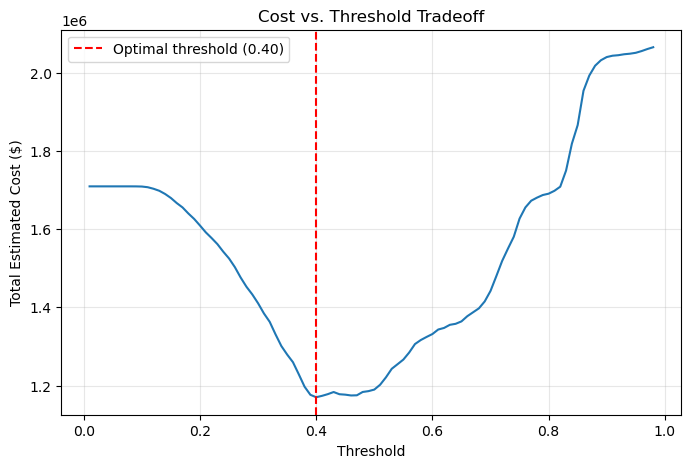

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'])
plt.axvline(best_row['threshold'], color='red', linestyle='--', label=f"Optimal threshold ({best_row['threshold']:.2f})")
plt.xlabel('Threshold')
plt.ylabel('Total Estimated Cost ($)')
plt.title('Cost vs. Threshold Tradeoff')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../docs/cost_threshold_curve.png', dpi=150)
plt.show()

Cost-based threshold optimization identified 0.40 as the operating point minimizing total expected cost ($1,170,025), a 1.6% reduction versus a naive 0.5 threshold. The modest size of this improvement reflects the model's precision ceiling (peaking near 19% even at high thresholds) - with only 13 interpretable features, the model has limited ability to sharply separate cost outcomes by threshold alone. This suggests the larger cost-reduction lever lies in improving the underlying model (e.g., incorporating the anonymized V-features via the benchmark approach) rather than threshold tuning alone.

## Operational Recommendation Memo

**To:** Fraud Strategy Leadership
**Re:** Recommended transaction review threshold

**Recommendation:** Set the fraud score threshold at **0.40** for the primary 
review queue.

**Decision framework:**
| Risk Score Range | Action | Rationale |
|---|---|---|
| Above 0.40 | Hold for manual review | Cost of a missed fraud transaction outweighs review labor cost at this range |
| Below 0.40 | Auto-approve | Preserves customer experience; expected fraud loss in this range is lower than the cost of added friction |

**Expected impact** (based on a 118,108-transaction held-out test sample, 
illustrative costs: $500 per missed fraud, $15 per false-positive review):
- Fraud caught: 3,081 of 4,133 total fraud cases (74.5% recall)
- False positives generated: 42,935 (legitimate transactions routed to review)
- Total estimated cost: $1,170,025, a **$19,560 reduction** (1.6%) versus a 
  naive 0.5 threshold

**Why the improvement looks modest in percentage terms:** the underlying 
model's precision ceiling (peaking at 19% even at strict thresholds) limits 
how much any single threshold choice can move total cost — the larger lever 
is model precision itself, not threshold tuning. At scale, however, even this 
margin compounds: the $19,560 savings on this sample equate to roughly $166 
per 1,000 transactions processed, which becomes material at production volume.

**Tradeoff being made:** this threshold accepts a substantial false-positive 
volume (42,935 legitimate transactions delayed for review) in exchange for 
catching three-quarters of fraud cases. A stricter threshold (e.g., 0.6-0.7) 
would cut false positives significantly but would also raise missed fraud 
from 1,052 to over 2,500 cases — a tradeoff leadership should weigh against 
review team capacity and customer experience priorities.

**Caveats:** Costs used here are illustrative placeholders, not validated 
against actual review labor rates or fraud loss figures — production 
deployment would require these to be recalibrated with real operational data 
before the threshold is finalized.